Sentiment Analysis of Text Data

Objective

The objective of this project is to build a machine learning model that classifies text data into three sentiment categories: Positive, Negative, and Neutral.

The analysis aims to provide insights into public opinion and customer feedback by automatically identifying the sentiment expressed in textual data.

Technology Stack

* Python
* Pandas
* Scikit-learn
* NLTK
* Matplotlib
* Seaborn
* Jupyter Notebook

Project Workflow

1. Load and inspect the dataset.
2. Analyze the distribution of sentiment classes.
3. Pre-process the text data.
4. Convert text into numerical features using TF-IDF.
5. Split the dataset into training and testing sets.
6. Train at least two machine learning classifiers.
7. Evaluate model performance using accuracy, precision, recall, and F1-score.
8. Visualize the results using charts and word clouds.
9. Perform error analysis on incorrectly classified examples.
10. Compare the models and discuss their real-world applications.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

In [3]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [7]:
import sys
print(sys.executable)

C:\Users\User\AppData\Local\Programs\Python\Python314\python.exe


In [8]:
import sys
!{sys.executable} -m pip install nltk

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------------------- ---------------- 1.0/1.8 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 3.5 MB/s  0:00:00

   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [regex]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [9]:
import nltk
print(nltk.__version__)

3.10.3


In [10]:
import pandas as pd

df = pd.read_csv("Tweets_Sentiment_Dataset.csv")

df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,5.700000e+17,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2/24/2015 11:35,NaN,Eastern Time (US & Canada)
1,5.700000e+17,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2/24/2015 11:15,NaN,Pacific Time (US & Canada)
2,5.700000e+17,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2/24/2015 11:15,Lets Play,Central Time (US & Canada)
3,5.700000e+17,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2/24/2015 11:15,NaN,Pacific Time (US & Canada)
4,5.700000e+17,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2/24/2015 11:14,NaN,Pacific Time (US & Canada)


In [11]:
df.shape

(14640, 15)

In [13]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str')

In [14]:
df['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

In [15]:
df.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [16]:
df[['airline_sentiment', 'text']].isnull().sum()

airline_sentiment    0
text                 0
dtype: int64

In [17]:
df[['airline_sentiment', 'text']].head(10)

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...
5,negative,@VirginAmerica seriously would pay $30 a fligh...
6,positive,"@VirginAmerica yes, nearly every time I fly VX..."
7,neutral,@VirginAmerica Really missed a prime opportuni...
8,positive,"@virginamerica Well, I didn't…but NOW I DO! :-D"
9,positive,"@VirginAmerica it was amazing, and arrived an ..."


In [18]:
df[['airline_sentiment', 'text']].dtypes

airline_sentiment    str
text                 str
dtype: object

In [20]:
import re
import string

In [21]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

print("Stopwords loaded:", len(stop_words))

Stopwords loaded: 318


In [22]:
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    # Join the words back together
    return ' '.join(words)

In [23]:
df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt today mean need trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [25]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])

print("TF-IDF shape:", X.shape)

TF-IDF shape: (14640, 5000)


In [26]:
y = df['airline_sentiment']

print(y.head())

0     neutral
1    positive
2     neutral
3    negative
4    negative
Name: airline_sentiment, dtype: str


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (11712, 5000)
Testing data: (2928, 5000)


In [28]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [30]:
y_pred_nb = nb_model.predict(X_test)

print(y_pred_nb[:10])

['negative' 'negative' 'negative' 'negative' 'negative' 'negative'
 'negative' 'positive' 'negative' 'negative']


In [33]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.7243852459016393


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

    negative       0.72      0.98      0.83      1835
     neutral       0.73      0.25      0.37       620
    positive       0.83      0.35      0.49       473

    accuracy                           0.72      2928
   macro avg       0.76      0.53      0.56      2928
weighted avg       0.74      0.72      0.68      2928



In [35]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [36]:
y_pred_lr = lr_model.predict(X_test)

print(y_pred_lr[:10])

['negative' 'negative' 'negative' 'negative' 'negative' 'negative'
 'negative' 'negative' 'negative' 'neutral']


In [37]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7636612021857924


In [38]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

    negative       0.78      0.94      0.86      1835
     neutral       0.62      0.42      0.50       620
    positive       0.82      0.53      0.64       473

    accuracy                           0.76      2928
   macro avg       0.74      0.63      0.67      2928
weighted avg       0.75      0.76      0.75      2928



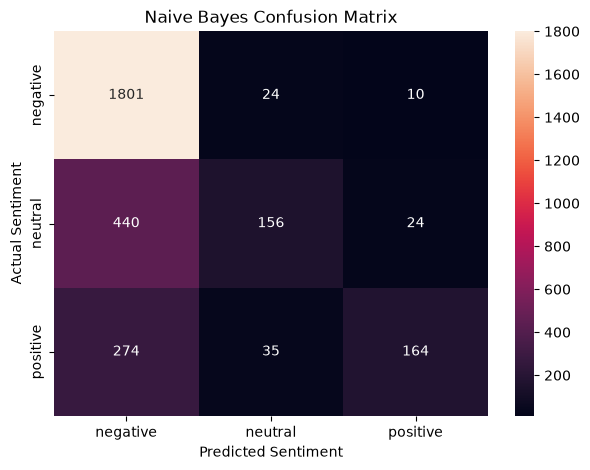

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=['negative', 'neutral', 'positive']
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive']
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

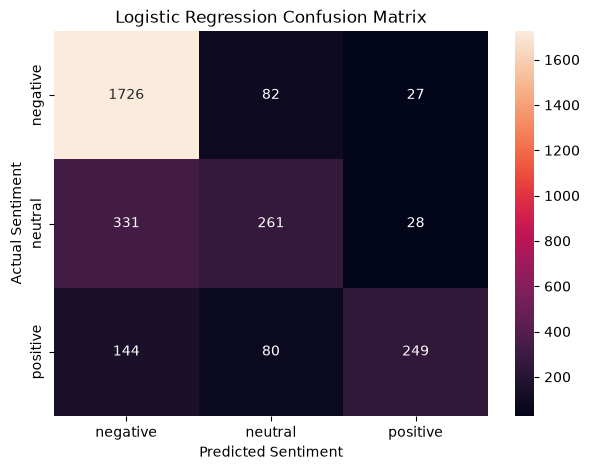

In [40]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=['negative', 'neutral', 'positive']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive']
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Logistic Regression Confusion Matrix')

plt.show()

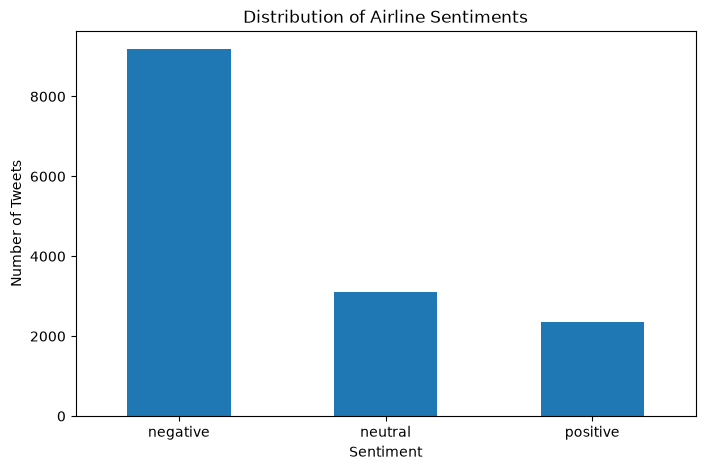

In [41]:
sentiment_counts = df['airline_sentiment'].value_counts()

plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind='bar')

plt.title('Distribution of Airline Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)

plt.show()

In [44]:
import sys
!{sys.executable} -m pip install wordcloud

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [45]:
from wordcloud import WordCloud

print("WordCloud imported successfully!")

WordCloud imported successfully!


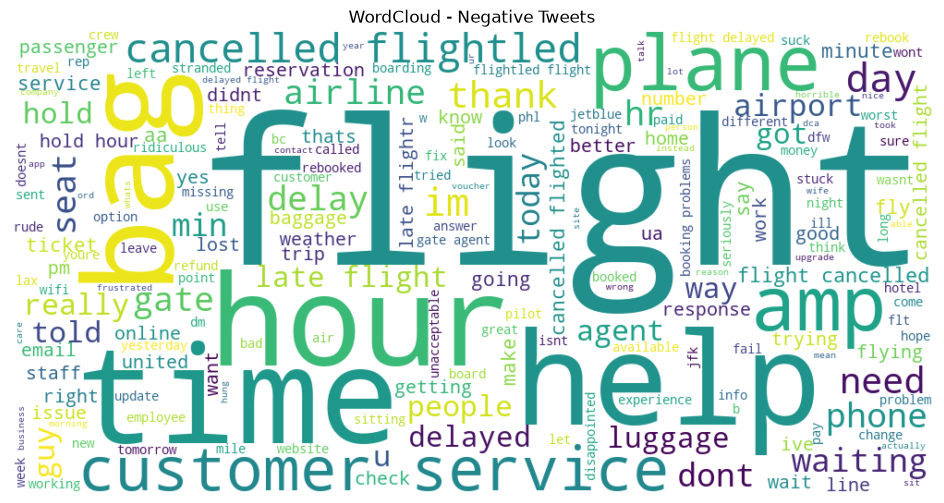

In [46]:
negative_text = ' '.join(
    df[df['airline_sentiment'] == 'negative']['clean_text']
)

wordcloud_negative = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Negative Tweets')
plt.show()

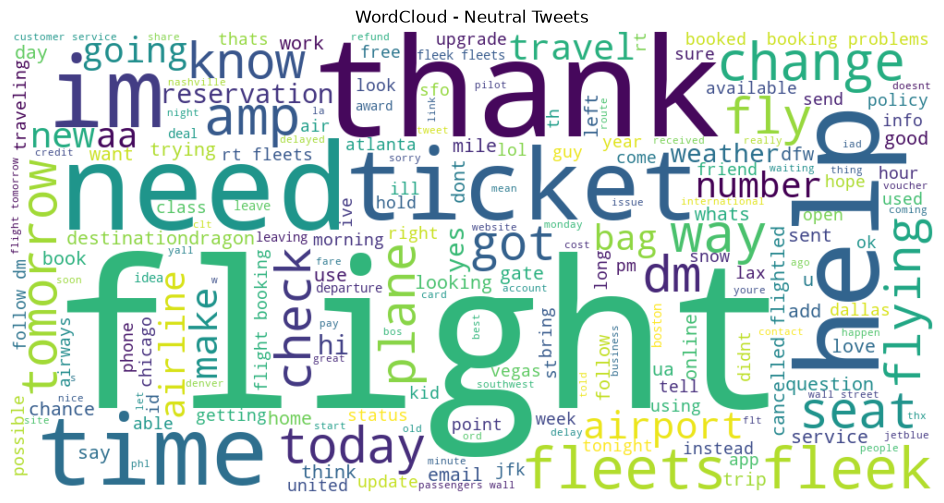

In [47]:
neutral_text = ' '.join(
    df[df['airline_sentiment'] == 'neutral']['clean_text']
)

wordcloud_neutral = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(neutral_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_neutral, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Neutral Tweets')
plt.show()

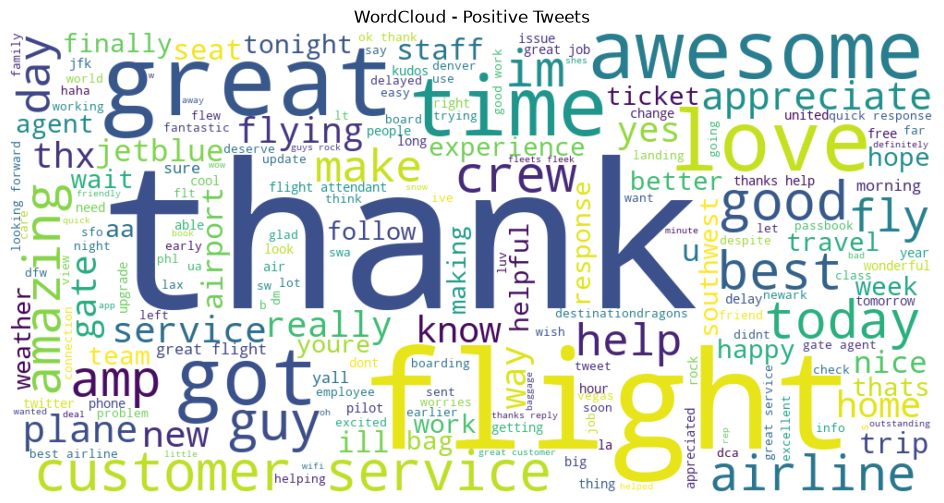

In [48]:
positive_text = ' '.join(
    df[df['airline_sentiment'] == 'positive']['clean_text']
)

wordcloud_positive = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Positive Tweets')
plt.show()

In [49]:
misclassified = df.loc[
    y_test.index[y_test != y_pred_lr],
    ['airline_sentiment', 'text']
].copy()

misclassified.columns = ['Actual Sentiment', 'Tweet']

misclassified.head(5)

,Actual Sentiment,Tweet
2998,neutral,@united past
7719,positive,@JetBlue would you say a delay is more likely?...
4006,neutral,@united This link in your tweet goes to someon...
4686,negative,@SouthwestAir When will the flight resume? I d...
3838,negative,@united of course but they were just as helple...


In [50]:
comparison = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [nb_accuracy, lr_accuracy],
    'Macro F1-Score': [0.56, 0.67],
    'Weighted F1-Score': [0.68, 0.75]
})

comparison

,Model,Accuracy,Macro F1-Score,Weighted F1-Score
0,Naive Bayes,0.724385,0.56,0.68
1,Logistic Regression,0.763661,0.67,0.75


## Conclusion

The sentiment analysis project classified airline tweets into negative, neutral, and positive sentiments using TF-IDF features and two machine learning algorithms: Multinomial Naive Bayes and Logistic Regression.

Naive Bayes achieved an accuracy of 72.44%, while Logistic Regression achieved a higher accuracy of 76.37%. Logistic Regression also achieved a higher macro F1-score of 0.67 compared with 0.56 for Naive Bayes.

The confusion matrices showed that both models performed best in identifying negative tweets, while neutral tweets were more difficult to classify correctly. Overall, Logistic Regression was selected as the better-performing model for this sentiment classification task.

The word clouds also helped visualize the most frequent words associated with negative, neutral, and positive tweets.

In [52]:
from sklearn.metrics import classification_report

nb_report = classification_report(
    y_test, y_pred_nb, output_dict=True
)

lr_report = classification_report(
    y_test, y_pred_lr, output_dict=True
)

comparison = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [
        nb_report['accuracy'],
        lr_report['accuracy']
    ],
    'Macro F1-Score': [
        nb_report['macro avg']['f1-score'],
        lr_report['macro avg']['f1-score']
    ],
    'Weighted F1-Score': [
        nb_report['weighted avg']['f1-score'],
        lr_report['weighted avg']['f1-score']
    ]
})

comparison

,Model,Accuracy,Macro F1-Score,Weighted F1-Score
0,Naive Bayes,0.724385,0.563507,0.677029
1,Logistic Regression,0.763661,0.665569,0.745538
